# Name: Angel Vasquez & Priyanshu Rathor

# Monday Class: Both Present
# Wednsday Class: Both Present

Dataset: https://www.kaggle.com/datasets/atharvaingle/crop-recommendation-dataset

In [1]:
from sklearn import datasets
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df = pd.read_csv('Crop_recommendation.csv')
df

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice
...,...,...,...,...,...,...,...,...
2195,107,34,32,26.774637,66.413269,6.780064,177.774507,coffee
2196,99,15,27,27.417112,56.636362,6.086922,127.924610,coffee
2197,118,33,30,24.131797,67.225123,6.362608,173.322839,coffee
2198,117,32,34,26.272418,52.127394,6.758793,127.175293,coffee


In [3]:
# Extract features and labels
X = df.drop("label", axis=1)
y = df["label"]

# Encode crop names into numbers
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Feature shape:", X.shape)
print("Target shape:", y_encoded.shape)

Feature shape: (2200, 7)
Target shape: (2200,)


In [4]:
# Split the data into training (70%) and testing (30%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state=42)

In [5]:
#Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [6]:
# Polynomial kernel (draws polynomial curves)
print("Polynomial kernel (degree=3):")
svm_poly = SVC(kernel='poly', degree=3, C=1.0, gamma='scale')
svm_poly.fit(X_train_scaled, y_train)
y_pred_poly = svm_poly.predict(X_test_scaled)
accuracy_poly = accuracy_score(y_test, y_pred_poly)
print(f"  - Accuracy: {accuracy_poly * 100:.2f}%")

Polynomial kernel (degree=3):
  - Accuracy: 90.91%


In [7]:
# Detail report
print("DETAILED CLASSIFICATION REPORT (POLYNOMIAL KERNEL)")

print(classification_report(y_test, y_pred_poly, target_names=label_encoder.classes_))

DETAILED CLASSIFICATION REPORT (POLYNOMIAL KERNEL)
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        34
      banana       1.00      0.96      0.98        26
   blackgram       0.83      0.92      0.87        26
    chickpea       1.00      1.00      1.00        34
     coconut       1.00      1.00      1.00        33
      coffee       1.00      0.83      0.91        30
      cotton       1.00      1.00      1.00        28
      grapes       1.00      1.00      1.00        23
        jute       0.71      0.88      0.79        34
 kidneybeans       0.97      1.00      0.99        36
      lentil       0.83      0.91      0.87        22
       maize       0.47      1.00      0.64        26
       mango       0.97      0.97      0.97        32
   mothbeans       1.00      0.74      0.85        34
    mungbean       0.86      1.00      0.92        30
   muskmelon       1.00      1.00      1.00        24
      orange       1.00      0

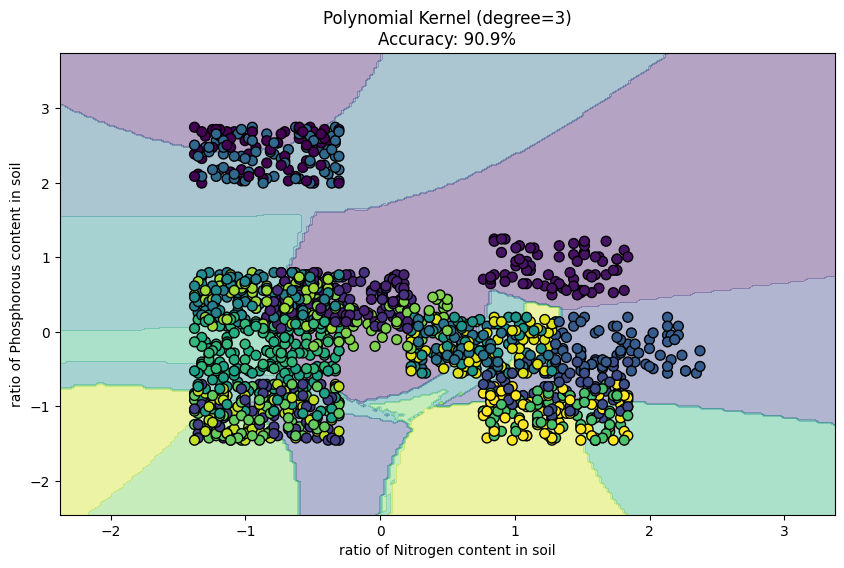

In [8]:
# SIMPLE VISUALIZATION

# For visualization, use only the first 2 features
X_2d = df[["N", "P"]].values
y_2d = y_encoded

X_train_2d, X_test_2d, y_train_2d, y_test_2d = train_test_split(
    X_2d, y_2d, test_size=0.3, random_state=42
)

# Scale the 2D data
scaler_2d = StandardScaler()
X_train_2d_scaled = scaler_2d.fit_transform(X_train_2d)
X_test_2d_scaled = scaler_2d.transform(X_test_2d)

# Train polynomial model on 2D data
svm_poly_2d = SVC(kernel='poly', degree=3, C=1.0, gamma='scale')
svm_poly_2d.fit(X_train_2d_scaled, y_train_2d)

# Create mesh grid
x_min = X_train_2d_scaled[:, 0].min() - 1
x_max = X_train_2d_scaled[:, 0].max() + 1
y_min = X_train_2d_scaled[:, 1].min() - 1
y_max = X_train_2d_scaled[:, 1].max() + 1
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

# Predict over grid
Z = svm_poly_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot decision regions
plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, alpha=0.4, cmap='viridis')
plt.scatter(
    X_train_2d_scaled[:, 0],
    X_train_2d_scaled[:, 1],
    c=y_train_2d,
    edgecolors='k',
    cmap='viridis',
    s=50
)

plt.title(f'Polynomial Kernel (degree=3)\nAccuracy: {accuracy_poly*100:.1f}%')
plt.xlabel("ratio of Nitrogen content in soil")
plt.ylabel("ratio of Phosphorous content in soil")
plt.show()

In [12]:
# NEW DATA PREDICTION (USER INPUT)

print("\nEnter new soil and environmental values:")

N = float(input("Nitrogen (N): "))
P = float(input("Phosphorus (P): "))
K = float(input("Potassium (K): "))
temperature = float(input("Temperature: "))
humidity = float(input("Humidity: "))
ph = float(input("pH: "))
rainfall = float(input("Rainfall: "))

# Create input as a DataFrame with correct column names
new_data = pd.DataFrame([{
    "N": N,
    "P": P,
    "K": K,
    "temperature": temperature,
    "humidity": humidity,
    "ph": ph,
    "rainfall": rainfall
}])

# Scale the input
new_data_scaled = scaler.transform(new_data)

# Predict
prediction = svm_poly.predict(new_data_scaled)

# If prediction is numeric, decode it
if np.issubdtype(type(prediction[0]), np.integer):
    predicted_crop = label_encoder.inverse_transform(prediction)[0]
else:
    predicted_crop = prediction[0]

print(f"\nRecommended Crop: {predicted_crop}")


Enter new soil and environmental values:
Nitrogen (N): 34
Phosphorus (P): 45
Potassium (K): 23
Temperature: 54
Humidity: 23
pH: 45
Rainfall: 203

Recommended Crop: chickpea


# Summary:
The dataset used in this project comes from Kaggle and is designed for crop recommendation in precision agriculture, meaning it helps determine the best crop to grow based on soil and environmental conditions. It includes features such as nitrogen (N), phosphorus (P), potassium (K), temperature, humidity, pH, and rainfall, all of which are important factors that affect plant growth. Each row represents a set of conditions along with the correct crop label, allowing us to train a model to make predictions. The goal of the dataset is to support data-driven farming decisions and improve agricultural yield by recommending the most suitable crop for specific conditions .

In this project, I used a Support Vector Machine (SVM) with a polynomial kernel to model the relationship between these environmental factors and crop type. I first prepared the data by separating the features and target variable, encoding the crop labels into numbers, and splitting the data into training and testing sets. I also applied feature scaling to ensure all variables were treated equally. The polynomial kernel was chosen because it can capture more complex, curved relationships in the data rather than just straight-line separations. After training the model, I tested it on unseen data and found that it achieved high accuracy, meaning it was able to correctly predict the appropriate crop in most cases. Overall, the results show that the model successfully learned patterns in the dataset and could be used in real-world scenarios to help farmers choose the best crops based on soil nutrients and climate conditions.